# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [3]:
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt


### Step 1. Load the data

In [5]:
pd.read_csv("../../../datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv").head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [6]:
df = pd.read_csv("../../../datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
print(df.columns)

Index(['Hours_Studied', 'Marks'], dtype='str')


In [7]:
X = df[["Hours_Studied"]]
y = df["Marks"]

### Step 2.b print the type of each

In [8]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [9]:
print("Target y is numerical")
print("This task is regression")

Target y is numerical
This task is regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 1)
y shape: (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [11]:
print("X summary:")
print(X.describe())

print("\ny summary:")
print(y.describe())

X summary:
       Hours_Studied
count     100.000000
mean        5.376300
std         2.593013
min         1.050000
25%         3.175000
50%         5.565000
75%         7.255000
max         9.870000

y summary:
count    100.000000
mean      46.360200
std       14.284805
min       20.190000
25%       33.675000
50%       47.485000
75%       57.377500
max       73.260000
Name: Marks, dtype: float64


### Step 5. Plot the feature vs the target

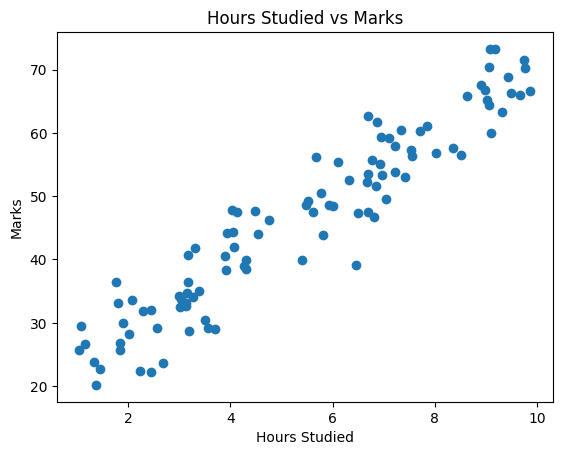

In [12]:
plt.scatter(X, y)
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours Studied vs Marks")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [13]:
correlation_value = X.iloc[:, 0].corr(y)

if correlation_value > 0:
    relationship = "Increasing (Positive Correlation)"
elif correlation_value < 0:
    relationship = "Decreasing (Negative Correlation)"
else:
    relationship = "None (No Correlation)"

print(f"Correlation Coefficient: {correlation_value:.2f}")
print(f"The relationship is: {relationship}")

Correlation Coefficient: 0.95
The relationship is: Increasing (Positive Correlation)


### Step 7. Initialize a `LinearRegression` model

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
print(model)

LinearRegression()


### Step 8. Split the dataset into train and test sets

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 1)
X_test shape: (20, 1)
y_train shape: (80,)
y_test shape: (20,)


### Step 9.a Train the model on the training set

In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [17]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 5.164438413499556
Intercept: 18.538578512317276


### Step 9.c how much marks do we get per 1 hour of study?

In [18]:
marks_per_hour = model.coef_[0]
print(f"For every 1 extra hour of study, marks increase by {marks_per_hour:.2f}")

For every 1 extra hour of study, marks increase by 5.16


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [19]:
marks_for_10_min = slope * (10/60)
print(f"Marks gained for 10 extra minutes of study: {marks_for_10_min:.2f}")

Marks gained for 10 extra minutes of study: 0.86


### Step 9.e if one doesn't study at all, how much marks do they get?

In [20]:
print(f"If a student does not study at all, predicted marks = {intercept:.2f}")

If a student does not study at all, predicted marks = 18.54


### Step 10. Evaluate the model on the test set

In [21]:
test_score = model.score(X_test, y_test)
print("R^2 score:", test_score)

R^2 score: 0.9258085525213727


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [25]:
X_sample = X_test.head(3)
y_true = y_test.head(3)
y_sample_pred = model.predict(X_sample)

comparison = pd.DataFrame({
    'Hours Studied': X_sample['Hours_Studied'].values,
    'Actual Marks': y_true.values,
    'Predicted Marks': y_sample_pred
})

comparison['Error'] = comparison['Actual Marks'] - comparison['Predicted Marks']

print(comparison)

   Hours Studied  Actual Marks  Predicted Marks     Error
0           3.02         32.50        34.135183 -1.635183
1           8.90         67.54        64.502080  3.037920
2           6.78         55.70        53.553471  2.146529


### Step 12. Plot the data and the regression line

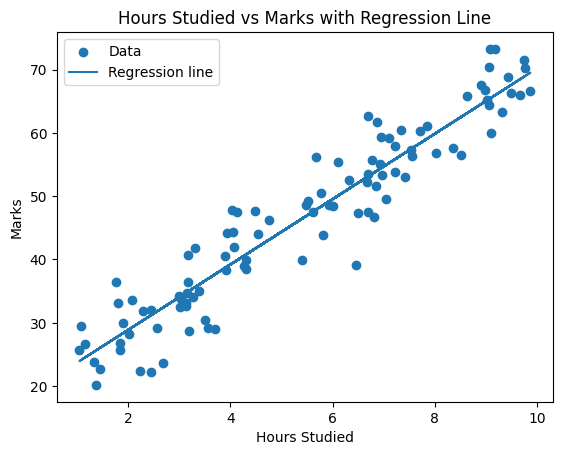

In [24]:
y_line = model.predict(X)

plt.scatter(X.iloc[:, 0], y, label="Data")
plt.plot(X.iloc[:, 0], y_line, label="Regression line")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours Studied vs Marks with Regression Line")
plt.legend()
plt.show()